# Plot multi-lead predictions for predicting hurricane track (distance) errors.
author: Elizabeth A. Barnes and Randal J. Barnes

In [1]:
%matplotlib inline
%load_ext autotime

import sys
import importlib as imp
import warnings
from shapely.errors import ShapelyDeprecationWarning

warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning)

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import multivariate_normal
from silence_tensorflow import silence_tensorflow
import pandas as pd
import cartopy as ct
import plots

import experiment_settings
import mahalanobis
from build_data import build_data
import data_info

time: 2.8 s (started: 2022-12-15 05:48:07 -07:00)


In [2]:
__author__ = "Randal J Barnes and Elizabeth A. Barnes"
__version__ = "13 December 2022"

DATA_PATH = "data/"
MODEL_PATH = "saved_models/"
FIGURE_PATH = "figures/analysis/"
PREDICTIONS_PATH = "saved_predictions/"

time: 482 µs (started: 2022-12-15 05:48:11 -07:00)


In [3]:
plt.style.use("seaborn-white")
mpl.rcParams['savefig.dpi'] = 600
mpl.rcParams["figure.dpi"] = 100
dpiFig = 600
plots.set_plot_rc()
np.warnings.filterwarnings("ignore", category=np.VisibleDeprecationWarning)

time: 595 µs (started: 2022-12-15 05:48:12 -07:00)


In [4]:
# Ian
RNG_SEED = 1
TESTING_YEAR = 2022

# Norman
# RNG_SEED = 1
# TESTING_YEAR = 2018

time: 286 µs (started: 2022-12-15 05:48:13 -07:00)


In [5]:
EXP_NAME_VEC = (
    # "centered_bivariate_normal_000_EPCP24",

    "centered_bivariate_normal_100_EPCP12",
    "centered_bivariate_normal_101_EPCP24",
    "centered_bivariate_normal_102_EPCP36",
    "centered_bivariate_normal_103_EPCP48",
    "centered_bivariate_normal_104_EPCP60",
    "centered_bivariate_normal_105_EPCP72",
    "centered_bivariate_normal_106_EPCP84",
    "centered_bivariate_normal_107_EPCP96",
    "centered_bivariate_normal_108_EPCP108",
    "centered_bivariate_normal_109_EPCP120",

    "centered_bivariate_normal_200_AL12",
    "centered_bivariate_normal_201_AL24",
    "centered_bivariate_normal_202_AL36",
    "centered_bivariate_normal_203_AL48",
    "centered_bivariate_normal_204_AL60",
    "centered_bivariate_normal_205_AL72",
    "centered_bivariate_normal_206_AL84",
    "centered_bivariate_normal_207_AL96",
    "centered_bivariate_normal_208_AL108",
    "centered_bivariate_normal_209_AL120",

    )


time: 466 µs (started: 2022-12-15 05:48:13 -07:00)


In [6]:
# GET PREDICTIONS
df_pred_test = pd.DataFrame()

for exp_name in EXP_NAME_VEC:
    settings = experiment_settings.get_settings(exp_name)

    # Create the model name.
    model_name = (
            exp_name
            + "_"
            + str(TESTING_YEAR)
            + "_"
            + settings["uncertainty_type"]
            + "_"
            + f"rng_seed_{RNG_SEED}"
    )
    try:
        prediction_filename = PREDICTIONS_PATH + model_name + "_testing_predictions.csv"
        df = pd.read_csv(prediction_filename)
    except:
        continue

    settings["rng_seed"] = RNG_SEED
    settings["years_test"] = (TESTING_YEAR,)
    df["exp_name"] = exp_name
    df_pred_test = pd.concat([df_pred_test, df], axis=0)

time: 47.4 ms (started: 2022-12-15 05:48:14 -07:00)


# Plot Results

In [65]:
if TESTING_YEAR == 2022:
    storm = {"storm_name": "IAN",
             "pred_time": 92318,
             "extent": [-100,-70,10,35],
             "nhc_cone_radius": [26, 39, 52, 67, 84, 100, 142, 200]
             }
elif TESTING_YEAR == 2018:
    storm = {"storm_name": "NORMAN",
             "pred_time": 90306,
             "extent": [195, 360-135, 5, 35],
             }
else:
    raise NotImplementedError('no such storm to plot')

time: 945 µs (started: 2022-12-15 06:19:32 -07:00)


## Plot vector ellipses

84 dataframe is empty
108 dataframe is empty


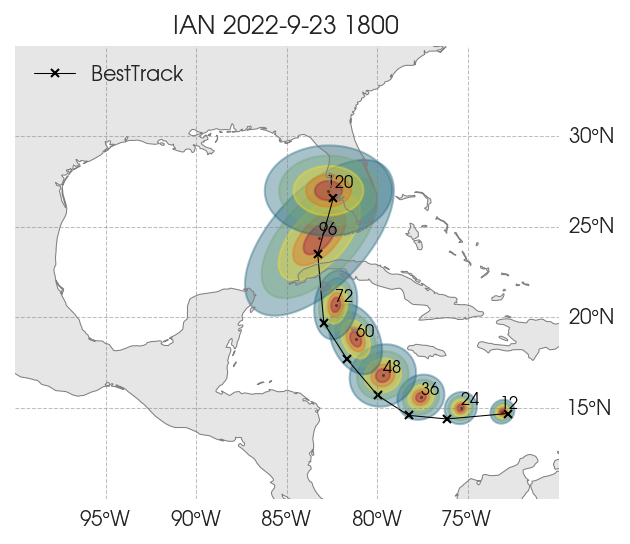

time: 3.2 s (started: 2022-12-15 06:51:00 -07:00)


In [106]:
imp.reload(mahalanobis)
imp.reload(plots)

df_storm = df_pred_test.loc[
    (df_pred_test["Name"] == storm["storm_name"]) & (df_pred_test["time"] == storm["pred_time"])]

fig = plt.figure(dpi=150, )
ax = fig.add_subplot(1, 1, 1, projection=ct.crs.PlateCarree(central_longitude=0.))
details = plots.plot_probability_ellipses(
    df_storm,
    ax=ax,
    leadtimes=np.arange(12,120+12, 12),
    contours=(.1, .25, .5, .75, .9,),
    extent = storm["extent"],
    alpha=.4,
    vector=True,
)

# save the figure
plt.savefig(
    FIGURE_PATH + 'probability_ellipses_' + EXP_NAME_VEC[0] + '_' + details.replace(' ', '_') + '.png',
    dpi=dpiFig,
    bbox_inches='tight',
    )
plt.show()

## Plot banana cone

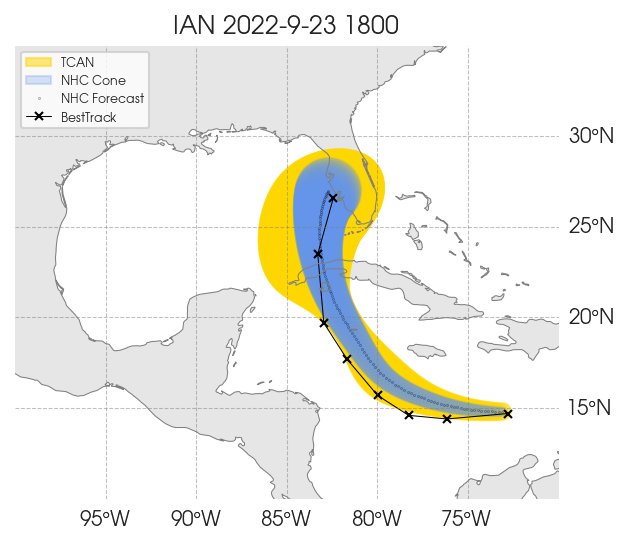

time: 5.68 s (started: 2022-12-15 07:01:39 -07:00)


In [120]:
imp.reload(mahalanobis)
imp.reload(plots)

df_storm = df_pred_test.loc[
    (df_pred_test["Name"] == storm["storm_name"]) & (df_pred_test["time"] == storm["pred_time"])].copy()
df_storm["nhc_cone_radius"] = storm["nhc_cone_radius"]
df_storm = df_storm.reset_index(drop=True)

#---------------------------
fig = plt.figure(dpi=150, )
ax = fig.add_subplot(1, 1, 1, projection=ct.crs.PlateCarree(central_longitude=0.))
details = plots.plot_banana_of_uncertainty(
    df_storm=df_storm,
    ax=ax,
    extent=storm["extent"],
    vector=True,
    colors=("gold", ),
    alpha=.5,
    plot_nhc_cone=True,
)

# save the figure
plt.savefig(
    FIGURE_PATH + 'banana_cone_' + EXP_NAME_VEC[0] + '_' + details.replace(' ', '_') + '.png',
    dpi=dpiFig,
    bbox_inches='tight',
)
plt.show()